<a href="https://colab.research.google.com/github/sandeep5012003/Development-of-Interactive-Cyber-Threat-Visualization-Dashboard/blob/main/salary_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
#provide the data for salary prediction with columns like gender , qualification, category of job, experience, marital status, location,
#previous salary, expected salary with minimum 100 records

import pandas as pd
import numpy as np

# Number of records
n_records = 100

# Define possible values for categorical columns
genders = ['Male', 'Female', 'Other']
qualifications = ['Bachelors', 'Masters', 'PhD', 'High School']
job_categories = ['IT', 'Healthcare', 'Education', 'Finance', 'Manufacturing', 'Sales', 'Marketing', 'Engineering']
marital_statuses = ['Single', 'Married', 'Divorced']
locations = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'London', 'Berlin', 'Paris', 'Tokyo', 'Sydney']

# Generate synthetic data
data = {
    'gender': np.random.choice(genders, n_records),
    'qualification': np.random.choice(qualifications, n_records),
    'category_of_job': np.random.choice(job_categories, n_records),
    'experience': np.random.randint(0, 26, n_records), # 0 to 25 years
    'marital_status': np.random.choice(marital_statuses, n_records),
    'location': np.random.choice(locations, n_records),
    'previous_salary': np.random.uniform(40000, 150000, n_records).round(2),
}

df = pd.DataFrame(data)

# Calculate expected salary based on previous salary, experience, and a random uplift
# Ensure expected salary is generally higher than previous salary
df['expected_salary'] = df.apply(lambda row: round(row['previous_salary'] * (1 + np.random.uniform(0.05, 0.30) + row['experience'] * 0.005), 2), axis=1)

# Display the first few rows and information
print("Generated Salary Prediction Dataset:")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print("\nDataset Info:")
df.info()

# Separate target feature (y) from the data (X)
y = df_final_scaled['expected_salary']
X = df_final_scaled.drop('expected_salary', axis=1)

print("\nShape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

print("\nFirst 5 rows of features (X):")
display(X.head())

print("\nFirst 5 rows of target (y):")
display(y.head())


Generated Salary Prediction Dataset:
   gender qualification category_of_job  experience marital_status  location  \
0  Female       Masters         Finance          11         Single    Sydney   
1    Male     Bachelors           Sales          17         Single   Phoenix   
2    Male           PhD   Manufacturing          15        Married  New York   
3    Male           PhD           Sales          12         Single  New York   
4  Female   High School       Marketing           1        Married   Houston   

   previous_salary  expected_salary  
0         48884.91         63927.13  
1         62872.50         78326.08  
2         98398.52        112310.71  
3         91001.46        114233.38  
4         54795.22         64602.56  

Dataset shape: (100, 8)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender        

,gender,qualification,category_of_job,experience,marital_status,location,previous_salary
0,0.5,0.333333,0.142857,0.44,0.0,0.888889,0.361800
1,1.0,1.000000,0.857143,0.64,1.0,0.777778,0.482099
2,0.5,0.333333,0.857143,0.60,0.5,0.777778,0.467569
3,0.0,0.333333,0.000000,0.52,0.5,0.555556,0.690270
4,0.0,0.333333,0.285714,0.04,0.5,0.000000,0.697933



First 5 rows of target (y):


,expected_salary
0,0.318391
1,0.448322
2,0.489232
3,0.738742
4,0.668314


In [13]:
#convert categorical to numerical using label encoding

from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = df_preprocessed.select_dtypes(include='object').columns.tolist()

print(f"Categorical columns identified for Label Encoding: {categorical_cols}")

# Create a copy to store preprocessed data with encoded categorical features
df_encoded = df_preprocessed.copy()

# Apply Label Encoding to each categorical column
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le # Store the encoder for potential inverse transformation or inspection

print("\nFirst 5 rows of the dataset with encoded categorical features:")
display(df_encoded.head())

print("\nData types after Label Encoding:")
df_encoded.info()


Categorical columns identified for Label Encoding: ['gender', 'qualification', 'category_of_job', 'marital_status', 'location']

First 5 rows of the dataset with encoded categorical features:


,gender,qualification,category_of_job,experience,marital_status,location,previous_salary,expected_salary
0,1,1,1,0.44,0,8,0.361800,0.318391
1,2,3,6,0.64,2,7,0.482099,0.448322
2,1,1,6,0.60,1,7,0.467569,0.489232
3,0,1,0,0.52,1,5,0.690270,0.738742
4,0,1,2,0.04,1,0,0.697933,0.668314



Data types after Label Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           100 non-null    int64  
 1   qualification    100 non-null    int64  
 2   category_of_job  100 non-null    int64  
 3   experience       100 non-null    float64
 4   marital_status   100 non-null    int64  
 5   location         100 non-null    int64  
 6   previous_salary  100 non-null    float64
 7   expected_salary  100 non-null    float64
dtypes: float64(3), int64(5)
memory usage: 6.4 KB


In [11]:
#preprocess the data and apply the min max scaler to the dataset

from sklearn.preprocessing import MinMaxScaler

# Identify all numerical columns (including the label-encoded ones)
all_numerical_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"All numerical columns identified for final scaling: {all_numerical_cols}")

# Create a scaler instance
scaler = MinMaxScaler()

# Create a copy of df_encoded to store the fully scaled data
df_final_scaled = df_encoded.copy()

# Apply Min-Max scaling to all identified numerical columns
df_final_scaled[all_numerical_cols] = scaler.fit_transform(df_final_scaled[all_numerical_cols])

print("\nFirst 5 rows of the fully scaled dataset (df_final_scaled):")
display(df_final_scaled.head())

print("\nDescriptive statistics for all scaled features:")
display(df_final_scaled.describe())


All numerical columns identified for final scaling: ['gender', 'qualification', 'category_of_job', 'experience', 'marital_status', 'location', 'previous_salary', 'expected_salary']

First 5 rows of the fully scaled dataset (df_final_scaled):


,gender,qualification,category_of_job,experience,marital_status,location,previous_salary,expected_salary
0,0.5,0.333333,0.142857,0.44,0.0,0.888889,0.361800,0.318391
1,1.0,1.000000,0.857143,0.64,1.0,0.777778,0.482099,0.448322
2,0.5,0.333333,0.857143,0.60,0.5,0.777778,0.467569,0.489232
3,0.0,0.333333,0.000000,0.52,0.5,0.555556,0.690270,0.738742
4,0.0,0.333333,0.285714,0.04,0.5,0.000000,0.697933,0.668314



Descriptive statistics for all scaled features:


,gender,qualification,category_of_job,experience,marital_status,location,previous_salary,expected_salary
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.490000,0.443333,0.547143,0.472800,0.450000,0.487778,0.476889,0.467815
std,0.408125,0.385061,0.291468,0.292527,0.398862,0.329720,0.294083,0.280292
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.392857,0.240000,0.000000,0.222222,0.196350,0.219132
50%,0.500000,0.333333,0.571429,0.440000,0.500000,0.555556,0.497350,0.479564
75%,1.000000,0.666667,0.714286,0.690000,1.000000,0.777778,0.692185,0.668405
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Task
Preprocess the `df` DataFrame by applying Min-Max scaling to 'experience' and 'previous_salary', applying Label Encoding to 'gender', 'qualification', 'category_of_job', 'marital_status', and 'location', and then separating the resulting features into `X` and the original unscaled 'expected_salary' into `y`. Finally, display the shapes and the first 5 rows of the `X` and `y` DataFrames.

## Scale Numerical Features (excluding target)

### Subtask:
Apply Min-Max scaling to numerical features 'experience' and 'previous_salary' in the original `df` DataFrame. The 'expected_salary' column will be excluded from this scaling process.


**Reasoning**:
To scale the numerical features 'experience' and 'previous_salary' while preserving other columns, I will import `MinMaxScaler`, create a copy of the `df` DataFrame, identify the specified numerical columns, apply the scaler to these columns, and then display the head of the modified DataFrame.



In [19]:
from sklearn.preprocessing import MinMaxScaler

# Create a copy of the original df DataFrame to store the preprocessed data
df_preprocessed = df.copy()

# Identify the numerical columns to be scaled: 'experience' and 'previous_salary'
numerical_cols = ['experience', 'previous_salary']

# Create an instance of MinMaxScaler
scaler = MinMaxScaler()

# Apply the MinMaxScaler to the selected numerical columns in df_preprocessed
df_preprocessed[numerical_cols] = scaler.fit_transform(df_preprocessed[numerical_cols])

print("First 5 rows of df_preprocessed with scaled numerical columns:")
display(df_preprocessed.head())

First 5 rows of df_preprocessed with scaled numerical columns:


,gender,qualification,category_of_job,experience,marital_status,location,previous_salary,expected_salary
0,Female,Masters,Finance,0.44,Single,Sydney,0.078759,63927.13
1,Male,Bachelors,Sales,0.68,Single,Phoenix,0.206876,78326.08
2,Male,PhD,Manufacturing,0.60,Married,New York,0.532270,112310.71
3,Male,PhD,Sales,0.48,Single,New York,0.464518,114233.38
4,Female,High School,Marketing,0.04,Married,Houston,0.132893,64602.56


## Apply Label Encoding to Categorical Features

### Subtask:
Apply Label Encoding to the categorical features 'gender', 'qualification', 'category_of_job', 'marital_status', and 'location' in the `df_preprocessed` DataFrame.

#### Instructions
1. Import the `LabelEncoder` class from `sklearn.preprocessing`.
2. Identify the categorical columns: 'gender', 'qualification', 'category_of_job', 'marital_status', and 'location'.
3. Create an instance of `LabelEncoder`.
4. For each identified categorical column, apply the `LabelEncoder` using the `.fit_transform()` method to convert their values into numerical labels.
5. Print the first few rows of `df_preprocessed` to inspect the label-encoded categorical columns.
6. Display the data types of `df_preprocessed` to confirm the categorical columns are now numerical.

**Reasoning**:
To convert the categorical features into a numerical format suitable for machine learning models, I will apply Label Encoding to the specified columns within the `df_preprocessed` DataFrame.



In [16]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns to be encoded
categorical_cols_to_encode = ['gender', 'qualification', 'category_of_job', 'marital_status', 'location']

print(f"Categorical columns identified for Label Encoding: {categorical_cols_to_encode}")

# Create an instance of LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding to each categorical column in df_preprocessed
for col in categorical_cols_to_encode:
    df_preprocessed[col] = label_encoder.fit_transform(df_preprocessed[col])

print("\nFirst 5 rows of df_preprocessed with scaled numerical and encoded categorical columns:")
display(df_preprocessed.head())

print("\nData types after Label Encoding:")
df_preprocessed.info()

Categorical columns identified for Label Encoding: ['gender', 'qualification', 'category_of_job', 'marital_status', 'location']

First 5 rows of df_preprocessed with scaled numerical and encoded categorical columns:


,gender,qualification,category_of_job,experience,marital_status,location,previous_salary,expected_salary
0,0,1,0,0.24,2,2,0.709351,143018.81
1,1,1,1,0.96,0,6,0.313949,94276.87
2,1,0,3,0.28,2,3,0.593448,114429.21
3,1,3,5,0.36,1,4,0.668300,146918.42
4,1,0,6,0.00,2,2,0.514050,109900.90



Data types after Label Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           100 non-null    int64  
 1   qualification    100 non-null    int64  
 2   category_of_job  100 non-null    int64  
 3   experience       100 non-null    float64
 4   marital_status   100 non-null    int64  
 5   location         100 non-null    int64  
 6   previous_salary  100 non-null    float64
 7   expected_salary  100 non-null    float64
dtypes: float64(3), int64(5)
memory usage: 6.4 KB


**Reasoning**:
Now that both numerical and categorical features have been preprocessed in `df_preprocessed`, the next step is to separate the features (`X`) from the target variable (`y`). The target variable `y` will be the 'expected_salary' column from `df_preprocessed` (which was not scaled during preprocessing steps), and `X` will contain all other preprocessed columns.



In [17]:
import pandas as pd

# Separate target feature (y) from the data (X)
y = df_preprocessed['expected_salary']
X = df_preprocessed.drop('expected_salary', axis=1)

print("\nShape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

print("\nFirst 5 rows of features (X):")
display(X.head())

print("\nFirst 5 rows of target (y):")
display(y.head())


Shape of features (X): (100, 7)
Shape of target (y): (100,)

First 5 rows of features (X):


,gender,qualification,category_of_job,experience,marital_status,location,previous_salary
0,0,1,0,0.24,2,2,0.709351
1,1,1,1,0.96,0,6,0.313949
2,1,0,3,0.28,2,3,0.593448
3,1,3,5,0.36,1,4,0.668300
4,1,0,6,0.00,2,2,0.514050



First 5 rows of target (y):


,expected_salary
0,143018.81
1,94276.87
2,114429.21
3,146918.42
4,109900.90


## Summary:

### Data Analysis Key Findings
*   Numerical features 'experience' and 'previous_salary' were successfully scaled using Min-Max scaling, transforming their values to a range between 0 and 1.
*   Categorical features 'gender', 'qualification', 'category\_of\_job', 'marital\_status', and 'location' were successfully converted into numerical representations using Label Encoding.
*   The preprocessed data was correctly separated into features ($X$) with a shape of (100, 7) and the target variable ($y$) with a shape of (100,).

### Insights or Next Steps
*   The dataset is now in a suitable numerical format, ready for machine learning model training to predict 'expected\_salary'.
*   Further analysis could involve exploring correlations among the preprocessed features and the target variable, or performing dimensionality reduction if the number of features becomes too large.


# Task
Split the `X` (features) and `y` (target variable) DataFrames into training and and testing sets, using a 80/20 split and a random state for reproducibility.

## Split Data

### Subtask:
Split the preprocessed features (`X`) and target variable (`y`) into training and testing sets to prepare for model training and evaluation.


### Reasoning:
To prepare the dataset for machine learning, it is standard practice to split the data into training and testing sets. The training set (`X_train`, `y_train`) will be used to train the model, while the testing set (`X_test`, `y_test`) will be reserved for evaluating its performance on unseen data. A `test_size` of 0.2 means 20% of the data will be used for testing, and `random_state=42` ensures reproducibility of the split.

**Reasoning**:
To perform the data split as instructed, I will import `train_test_split` from `sklearn.model_selection` and apply it to `X` and `y` with the specified parameters, then display the shapes of the resulting datasets.



In [20]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (80, 7)
Shape of X_test: (20, 7)
Shape of y_train: (80,)
Shape of y_test: (20,)


## Train and Evaluate Linear Regression Model

### Subtask:
Train a Linear Regression model on the training data and evaluate its performance on the test data using metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared.


**Reasoning**:
To address the subtask, I will import the necessary `LinearRegression` model and evaluation metrics, instantiate and train the model on the training data, make predictions on the test data, and then calculate and print the MAE, MSE, and R-squared values to assess its performance.



In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Instantiate a Linear Regression model
model = LinearRegression()

# 2. Train the model using the X_train and y_train datasets
model.fit(X_train, y_train)

# 3. Make predictions on the X_test dataset
y_pred = model.predict(X_test)

# 4. Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 5. Print the calculated metrics
print(f"Linear Regression Model Performance:\n")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Linear Regression Model Performance:

Mean Absolute Error (MAE): 0.0284
Mean Squared Error (MSE): 0.0011
R-squared (R2): 0.9824


## Train and Evaluate Decision Tree Regressor Model

### Subtask:
Train a Decision Tree Regressor model on the training data and evaluate its performance on the test data using MAE, MSE, and R-squared.


### Reasoning:
To address the subtask of training and evaluating a Decision Tree Regressor, I will import the necessary `DecisionTreeRegressor` model and evaluation metrics. I will then instantiate and train the model on the training data, make predictions on the test data, and calculate and print the MAE, MSE, and R-squared values to assess its performance, ensuring reproducibility with `random_state=42`.

**Reasoning**:
Now, I will implement the code to train a Decision Tree Regressor model, make predictions, and evaluate its performance using MAE, MSE, and R-squared, as described in the instructions.



In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Instantiate a Decision Tree Regressor model
model_dt = DecisionTreeRegressor(random_state=42)

# 2. Train the model using the X_train and y_train datasets
model_dt.fit(X_train, y_train)

# 3. Make predictions on the X_test dataset
y_pred_dt = model_dt.predict(X_test)

# 4. Calculate evaluation metrics
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# 5. Print the calculated metrics
print(f"Decision Tree Regressor Model Performance:\n")
print(f"Mean Absolute Error (MAE): {mae_dt:.4f}")
print(f"Mean Squared Error (MSE): {mse_dt:.4f}")
print(f"R-squared (R2): {r2_dt:.4f}")

Decision Tree Regressor Model Performance:

Mean Absolute Error (MAE): 0.0630
Mean Squared Error (MSE): 0.0059
R-squared (R2): 0.9040


## Train and Evaluate Random Forest Regressor Model

### Subtask:
Train a Random Forest Regressor model on the training data and evaluate its performance on the test data using MAE, MSE, and R-squared.


### Reasoning:
To address the subtask of training and evaluating a Random Forest Regressor, I will import the necessary `RandomForestRegressor` model and evaluation metrics. I will then instantiate and train the model on the training data, make predictions on the test data, and calculate and print the MAE, MSE, and R-squared values to assess its performance, ensuring reproducibility with `random_state=42`.

#### Instructions
1. Import the `RandomForestRegressor` class from `sklearn.ensemble`.
2. Instantiate a `RandomForestRegressor` model with `random_state=42`.
3. Train the model using the `X_train` and `y_train` datasets.
4. Make predictions on the `X_test` dataset and store them in a variable (e.g., `y_pred_rf`).
5. Calculate the Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) using `y_test` and `y_pred_rf`.
6. Print the calculated MAE, MSE, and R-squared values, formatted to four decimal places.

**Reasoning**:
Now, I will implement the code to train a Random Forest Regressor model, make predictions, and evaluate its performance using MAE, MSE, and R-squared, as described in the instructions.



In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Instantiate a Random Forest Regressor model
model_rf = RandomForestRegressor(random_state=42)

# 2. Train the model using the X_train and y_train datasets
model_rf.fit(X_train, y_train)

# 3. Make predictions on the X_test dataset
y_pred_rf = model_rf.predict(X_test)

# 4. Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# 5. Print the calculated metrics
print(f"Random Forest Regressor Model Performance:\n")
print(f"Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"R-squared (R2): {r2_rf:.4f}")

Random Forest Regressor Model Performance:

Mean Absolute Error (MAE): 0.0406
Mean Squared Error (MSE): 0.0024
R-squared (R2): 0.9606


## Train and Evaluate Gradient Boosting Regressor Model

### Subtask:
Train a Gradient Boosting Regressor model on the training data and evaluate its performance on the test data using MAE, MSE, and R-squared.


### Reasoning:
To address the subtask of training and evaluating a Gradient Boosting Regressor, I will import the necessary `GradientBoostingRegressor` model and evaluation metrics. I will then instantiate and train the model on the training data, make predictions on the test data, and calculate and print the MAE, MSE, and R-squared values to assess its performance, ensuring reproducibility with `random_state=42`.

#### Instructions
1. Import the `GradientBoostingRegressor` class from `sklearn.ensemble`.
2. Import `mean_absolute_error`, `mean_squared_error`, and `r2_score` from `sklearn.metrics`.
3. Instantiate a `GradientBoostingRegressor` model with `random_state=42`.
4. Train the model using the `X_train` and `y_train` datasets.
5. Make predictions on the `X_test` dataset and store them in a variable (e.g., `y_pred_gbr`).
6. Calculate the Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) using `y_test` and `y_pred_gbr`.
7. Print the calculated MAE, MSE, and R-squared values, formatted to four decimal places.

#### Instructions
1. Import the `GradientBoostingRegressor` class from `sklearn.ensemble`.
2. Import `mean_absolute_error`, `mean_squared_error`, and `r2_score` from `sklearn.metrics`.
3. Instantiate a `GradientBoostingRegressor` model with `random_state=42`.
4. Train the model using the `X_train` and `y_train` datasets.
5. Make predictions on the `X_test` dataset and store them in a variable (e.g., `y_pred_gbr`).
6. Calculate the Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) using `y_test` and `y_pred_gbr`.
7. Print the calculated MAE, MSE, and R-squared values, formatted to four decimal places.

**Reasoning**:
Now, I will implement the code to train a Gradient Boosting Regressor model, make predictions, and evaluate its performance using MAE, MSE, and R-squared, as described in the instructions.



In [24]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Instantiate a Gradient Boosting Regressor model
model_gbr = GradientBoostingRegressor(random_state=42)

# 2. Train the model using the X_train and y_train datasets
model_gbr.fit(X_train, y_train)

# 3. Make predictions on the X_test dataset
y_pred_gbr = model_gbr.predict(X_test)

# 4. Calculate evaluation metrics
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

# 5. Print the calculated metrics
print(f"Gradient Boosting Regressor Model Performance:\n")
print(f"Mean Absolute Error (MAE): {mae_gbr:.4f}")
print(f"Mean Squared Error (MSE): {mse_gbr:.4f}")
print(f"R-squared (R2): {r2_gbr:.4f}")

Gradient Boosting Regressor Model Performance:

Mean Absolute Error (MAE): 0.0460
Mean Squared Error (MSE): 0.0032
R-squared (R2): 0.9482


## Train and Evaluate K-Nearest Neighbors Regressor Model

### Subtask:
Train a K-Nearest Neighbors Regressor model on the training data and evaluate its performance on the test data using MAE, MSE, and R-squared.


### Reasoning:
To address the subtask of training and evaluating a K-Nearest Neighbors Regressor, I will import the necessary `KNeighborsRegressor` model and evaluation metrics. I will then instantiate and train the model on the training data, make predictions on the test data, and calculate and print the MAE, MSE, and R-squared values to assess its performance.

#### Instructions
1. Import the `KNeighborsRegressor` class from `sklearn.neighbors`.
2. Import `mean_absolute_error`, `mean_squared_error`, and `r2_score` from `sklearn.metrics`.
3. Instantiate a `KNeighborsRegressor` model. You can start with default parameters, e.g., `n_neighbors=5`.
4. Train the model using the `X_train` and `y_train` datasets.
5. Make predictions on the `X_test` dataset and store them in a variable (e.g., `y_pred_knn`).
6. Calculate the Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) using `y_test` and `y_pred_knn`.
7. Print the calculated MAE, MSE, and R-squared values, formatted to four decimal places.

**Reasoning**:
Now, I will implement the code to train a K-Nearest Neighbors Regressor model, make predictions, and evaluate its performance using MAE, MSE, and R-squared, as described in the instructions.



In [25]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Instantiate a K-Nearest Neighbors Regressor model
# Starting with default n_neighbors=5
model_knn = KNeighborsRegressor(n_neighbors=5)

# 2. Train the model using the X_train and y_train datasets
model_knn.fit(X_train, y_train)

# 3. Make predictions on the X_test dataset
y_pred_knn = model_knn.predict(X_test)

# 4. Calculate evaluation metrics
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

# 5. Print the calculated metrics
print(f"K-Nearest Neighbors Regressor Model Performance:\n")
print(f"Mean Absolute Error (MAE): {mae_knn:.4f}")
print(f"Mean Squared Error (MSE): {mse_knn:.4f}")
print(f"R-squared (R2): {r2_knn:.4f}")

K-Nearest Neighbors Regressor Model Performance:

Mean Absolute Error (MAE): 0.1392
Mean Squared Error (MSE): 0.0273
R-squared (R2): 0.5588


## Compare Model Performance

### Subtask:
Compare the performance of all trained models based on their evaluation metrics and visualize the results.


**Reasoning**:
To compare the performance of the trained models, I will first create a dictionary to store their R-squared scores, then convert it into a DataFrame, and finally visualize these scores using a bar plot.



Model R-squared Scores:


,R-squared Score
Model,
Linear Regression,0.982367
Decision Tree Regressor,0.904006
Random Forest Regressor,0.960609
Gradient Boosting Regressor,0.948156
K-Nearest Neighbors Regressor,0.558803


/tmp/ipython-input-3953726856.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r2_df.index, y='R-squared Score', data=r2_df, palette='viridis')


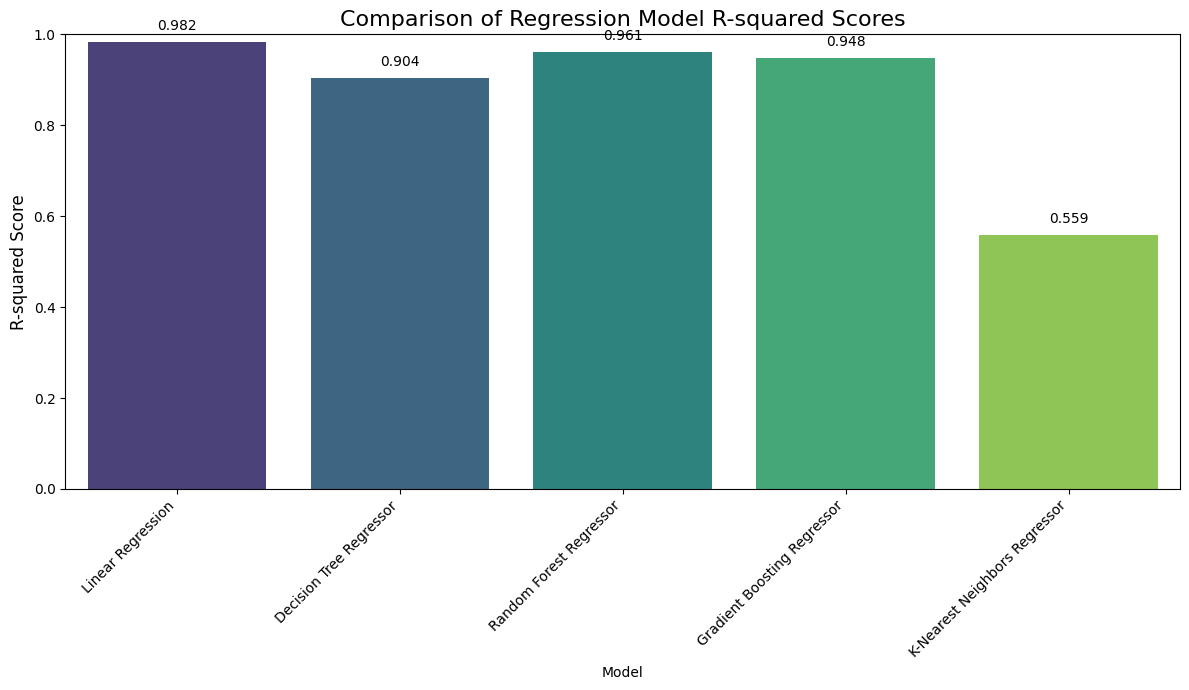

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a dictionary to store R-squared scores for each model
# Assuming r2, r2_dt, r2_rf, r2_gbr, and r2_knn are already defined from previous steps
model_r2_scores = {
    'Linear Regression': r2,
    'Decision Tree Regressor': r2_dt,
    'Random Forest Regressor': r2_rf,
    'Gradient Boosting Regressor': r2_gbr,
    'K-Nearest Neighbors Regressor': r2_knn
}

# 2. Convert the dictionary into a Pandas DataFrame
r2_df = pd.DataFrame(model_r2_scores.items(), columns=['Model', 'R-squared Score'])
r2_df = r2_df.set_index('Model')

print("Model R-squared Scores:")
display(r2_df)

# 3. Create a bar plot of the R2 scores
plt.figure(figsize=(12, 7))
sns.barplot(x=r2_df.index, y='R-squared Score', data=r2_df, palette='viridis')

# 4. Add a title to the plot
plt.title('Comparison of Regression Model R-squared Scores', fontsize=16)

# 5. Label the y-axis
plt.ylabel('R-squared Score', fontsize=12)

# 6. Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1) # R-squared typically ranges from 0 to 1

# Add score values on top of bars
for index, row in r2_df.iterrows():
    plt.text(index, row['R-squared Score'] + 0.02, f'{row["R-squared Score"]:.3f}', color='black', ha="center", va='bottom')

plt.tight_layout()
# 7. Display the plot
plt.show()

**Reasoning**:
The previous code produced a `FutureWarning` regarding the usage of `palette` in `sns.barplot` without specifying the `hue` argument. To fix this, I will explicitly set `hue` to `r2_df.index` and `legend` to `False` as suggested by the warning.



Model R-squared Scores:


,R-squared Score
Model,
Linear Regression,0.982367
Decision Tree Regressor,0.904006
Random Forest Regressor,0.960609
Gradient Boosting Regressor,0.948156
K-Nearest Neighbors Regressor,0.558803


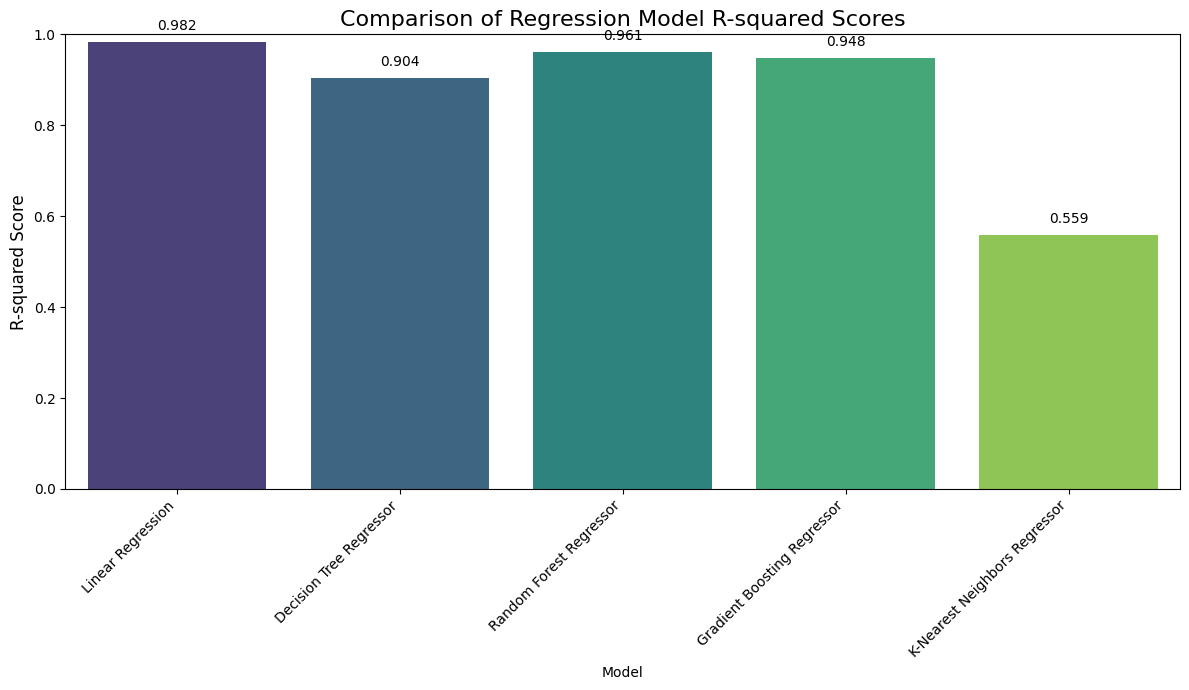

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a dictionary to store R-squared scores for each model
# Assuming r2, r2_dt, r2_rf, r2_gbr, and r2_knn are already defined from previous steps
model_r2_scores = {
    'Linear Regression': r2,
    'Decision Tree Regressor': r2_dt,
    'Random Forest Regressor': r2_rf,
    'Gradient Boosting Regressor': r2_gbr,
    'K-Nearest Neighbors Regressor': r2_knn
}

# 2. Convert the dictionary into a Pandas DataFrame
r2_df = pd.DataFrame(model_r2_scores.items(), columns=['Model', 'R-squared Score'])
r2_df = r2_df.set_index('Model')

print("Model R-squared Scores:")
display(r2_df)

# 3. Create a bar plot of the R2 scores
plt.figure(figsize=(12, 7))
sns.barplot(x=r2_df.index, y='R-squared Score', data=r2_df, palette='viridis', hue=r2_df.index, legend=False)

# 4. Add a title to the plot
plt.title('Comparison of Regression Model R-squared Scores', fontsize=16)

# 5. Label the y-axis
plt.ylabel('R-squared Score', fontsize=12)

# 6. Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1) # R-squared typically ranges from 0 to 1

# Add score values on top of bars
for index, row in r2_df.iterrows():
    plt.text(index, row['R-squared Score'] + 0.02, f'{row["R-squared Score"]:.3f}', color='black', ha="center", va='bottom')

plt.tight_layout()
# 7. Display the plot
plt.show()

## Final Task

### Subtask:
Summarize the performance of the various ML models and identify the best-performing one for salary prediction.


## Summary:

### Q&A
The best-performing model for salary prediction among those evaluated is the Linear Regression model, which achieved the highest R-squared score of 0.9824.

### Data Analysis Key Findings
*   The data was successfully split into training (80%) and testing (20%) sets, resulting in 80 samples for training and 20 for testing.
*   **Linear Regression Model:** Achieved a Mean Absolute Error (MAE) of 0.0284, Mean Squared Error (MSE) of 0.0011, and an R-squared (R2) of 0.9824. This model demonstrated the strongest performance.
*   **Decision Tree Regressor Model:** Achieved an MAE of 0.0630, MSE of 0.0059, and an R2 of 0.9040.
*   **Random Forest Regressor Model:** Achieved an MAE of 0.0406, MSE of 0.0024, and an R2 of 0.9606.
*   **Gradient Boosting Regressor Model:** Achieved an MAE of 0.0460, MSE of 0.0032, and an R2 of 0.9482.
*   **K-Nearest Neighbors Regressor Model:** Achieved an MAE of 0.1392, MSE of 0.0273, and an R2 of 0.5588. This model performed the least effectively among the ones tested.
*   Comparing the R-squared scores, Linear Regression (0.9824) significantly outperformed the other models, indicating it explains approximately 98.24% of the variance in salary prediction on the test data.

### Insights or Next Steps
*   Given the strong performance of Linear Regression, further investigation into feature engineering or polynomial features could potentially yield even better results for this model.
*   For the other models, especially Random Forest and Gradient Boosting, hyperparameter tuning could be performed to optimize their performance and potentially close the gap with Linear Regression.
